In [7]:
import numpy as np
import pandas as pd
np.random.seed(23) 

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

df = pd.concat([df , df1],ignore_index=True)

df = df.sample(40)

In [4]:
print(df.head())

    feature1  feature2  feature3  target
2  -0.367548 -1.137460 -1.322148       1
34  0.177061 -0.598109  1.226512       0
14  0.420623  0.411620 -0.071324       1
11  1.968435 -0.547788 -0.679418       1
12 -2.506230  0.146960  0.606195       1


In [8]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

In [9]:
# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [10]:
# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [11]:
# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [12]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [13]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

In [16]:

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch


class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        FancyArrowPatch.__init__(self, (0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, renderer.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        FancyArrowPatch.draw(self, renderer)

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(df['feature1'], df['feature2'], df['feature3'], 'o', markersize=8, color='blue', alpha=0.2)
ax.plot([df['feature1'].mean()], [df['feature2'].mean()], [df['feature3'].mean()], 'o', markersize=10, color='red', alpha=0.5)
for v in eigen_vectors.T:
    a = Arrow3D([df['feature1'].mean(), v[0]], [df['feature2'].mean(), v[1]], [df['feature3'].mean(), v[2]], mutation_scale=20, lw=3, arrowstyle="-|>", color="r")
    ax.add_artist(a)
ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.title('Eigenvectors')

plt.show()

AttributeError: 'Arrow3D' object has no attribute 'do_3d_projection'

<Figure size 700x700 with 1 Axes>

In [17]:
pc = eigen_vectors[0:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [18]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,0.599433,1.795862,1
1,1.056919,-0.212737,0
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1


In [19]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()

### ***Practice this on Some Numerical DataSet***

In [87]:
df = pd.read_csv("D:/Study/data_science/Machine_Learning/10. Handling Missing Values/50_Startups.csv")

print(df.head())

   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94


### For our practice we will remove categorical column

In [88]:
df = df.drop('State' , axis=1)
print(df.head())

   R&D Spend  Administration  Marketing Spend     Profit
0  165349.20       136897.80        471784.10  192261.83
1  162597.70       151377.59        443898.53  191792.06
2  153441.51       101145.55        407934.54  191050.39
3  144372.41       118671.85        383199.62  182901.99
4  142107.34        91391.77        366168.42  166187.94


In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   Profit           50 non-null     float64
dtypes: float64(4)
memory usage: 1.7 KB


In [90]:
# Basic Stats about the data
print(df.describe())

           R&D Spend  Administration  Marketing Spend         Profit
count      50.000000       50.000000        50.000000      50.000000
mean    73721.615600   121344.639600    211025.097800  112012.639200
std     45902.256482    28017.802755    122290.310726   40306.180338
min         0.000000    51283.140000         0.000000   14681.400000
25%     39936.370000   103730.875000    129300.132500   90138.902500
50%     73051.080000   122699.795000    212716.240000  107978.190000
75%    101602.800000   144842.180000    299469.085000  139765.977500
max    165349.200000   182645.560000    471784.100000  192261.830000


### **EDA**

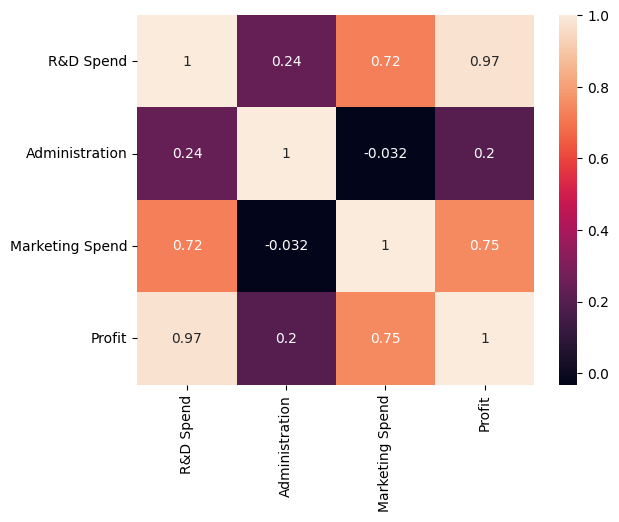

In [91]:
# (i) Correlation b/w features and feature vs target
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(df.corr(),annot=True)
plt.show()


### Feature Vs Target
- We see that R&D Spend has 0.97 correlation with Profit - Highly correlated -> Important Feature
- Administration has 0.2 correlation which means it not as important as the others
- Marketing also has decent correlation with 0.75 with Profit

### Feature Vs Feature
- R&D and Marketing has 0.72 correlation which is high but not very high so we can keep those cols

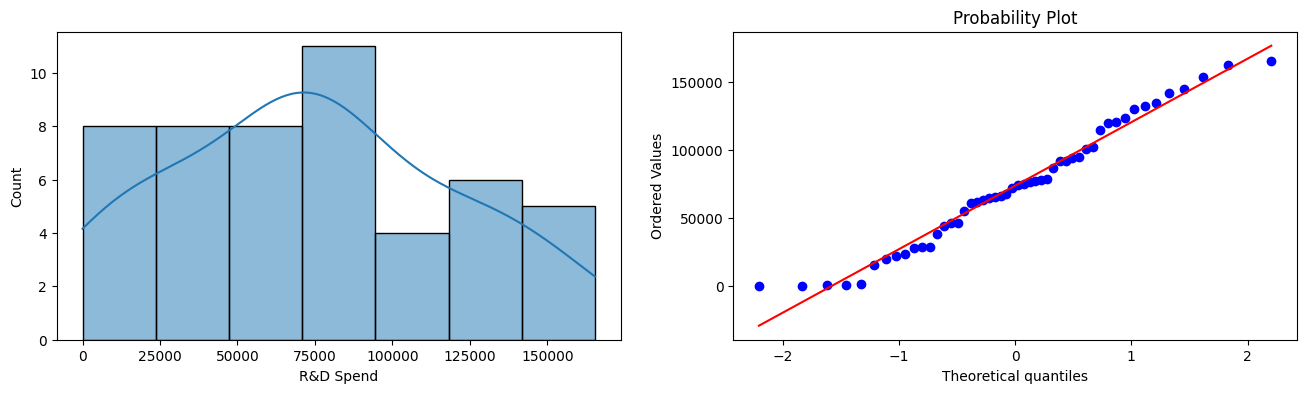

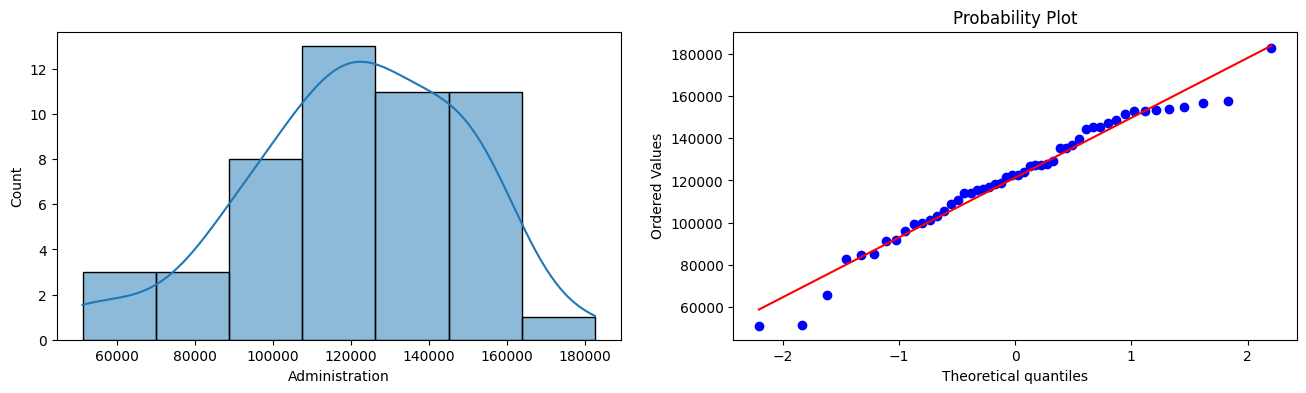

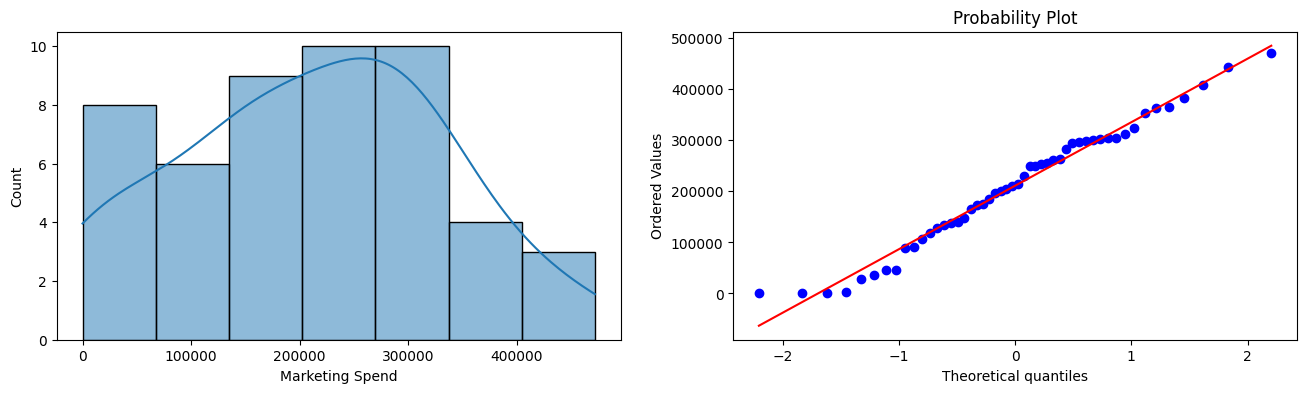

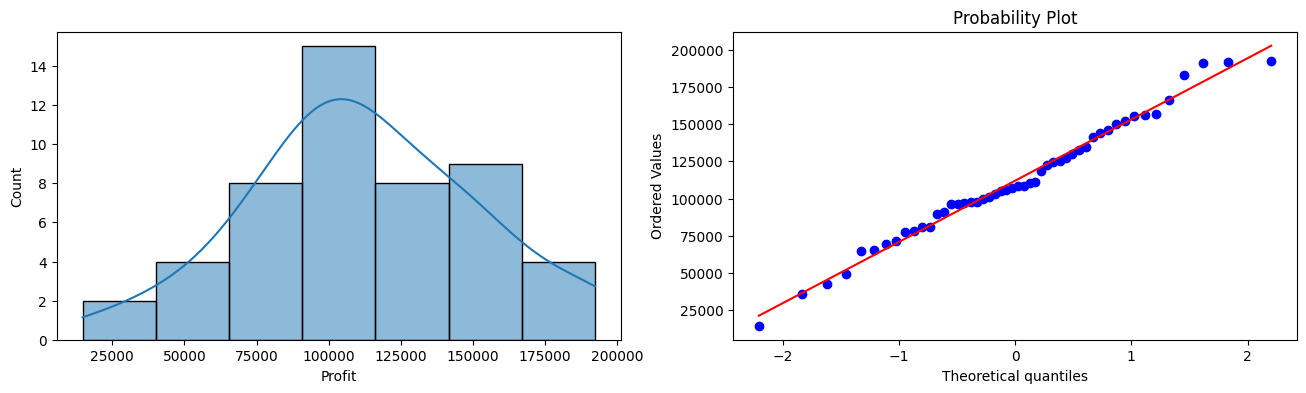

In [54]:
# Loop through all numerical columns
import scipy.stats as stats
for col in df.columns.to_list():
    
    fig,ax = plt.subplots(ncols=2,figsize=(16,4))
    
    sns.histplot(df[col], kde=True,ax = ax[0])
    stats.probplot(x=df[col] , plot=ax[1])

    
    plt.show()

### Fitting the model and evaluating before scaling

In [92]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2 , random_state=1)

lr.fit(X_train , y_train)

y_pred = lr.predict(X_test)

print(f'r2_score -> {r2_score(y_test , y_pred)}')

r2_score -> 0.9650940934427324


In [84]:
# Step 1 Scale the data
from sklearn.preprocessing import StandardScaler

df_features = df.iloc[:,:-1]
df_target = df.iloc[:,-1]
scale = StandardScaler()
scale.set_output(transform='pandas')

df_features = scale.fit_transform(df_features)

df = pd.concat([df_features , df_target],axis=1)


In [85]:
print(df.head())

   R&D Spend  Administration  Marketing Spend     Profit
0   2.016411        0.560753         2.153943  192261.83
1   1.955860        1.082807         1.923600  191792.06
2   1.754364       -0.728257         1.626528  191050.39
3   1.554784       -0.096365         1.422210  182901.99
4   1.504937       -1.079919         1.281528  166187.94


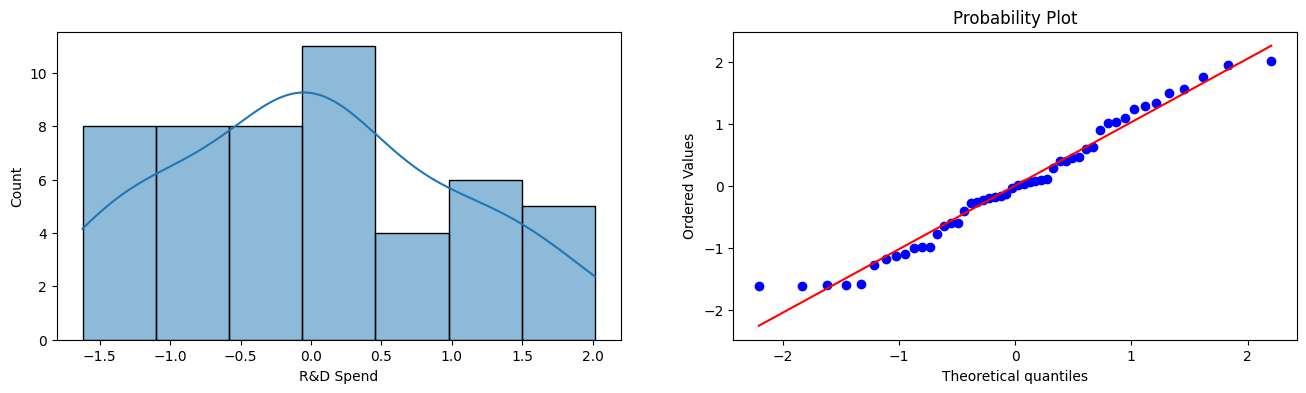

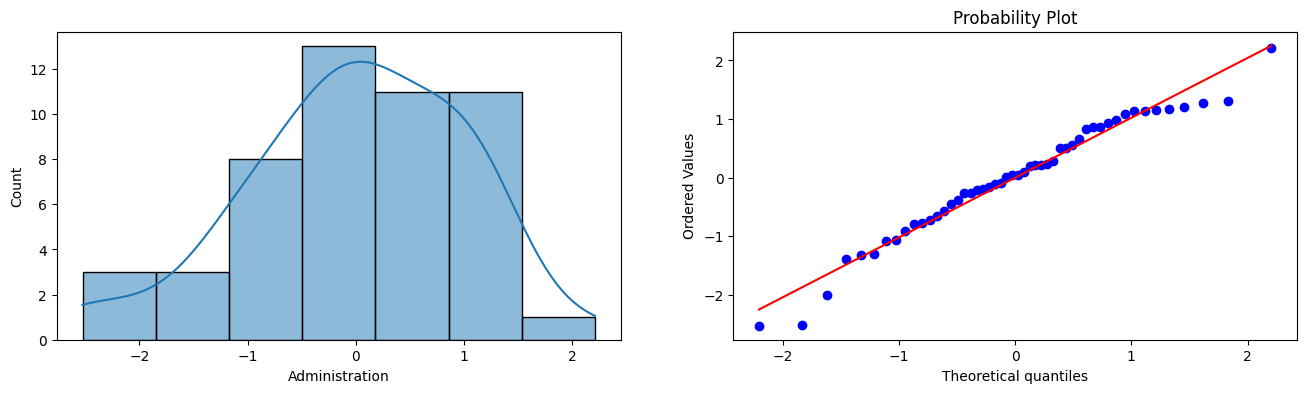

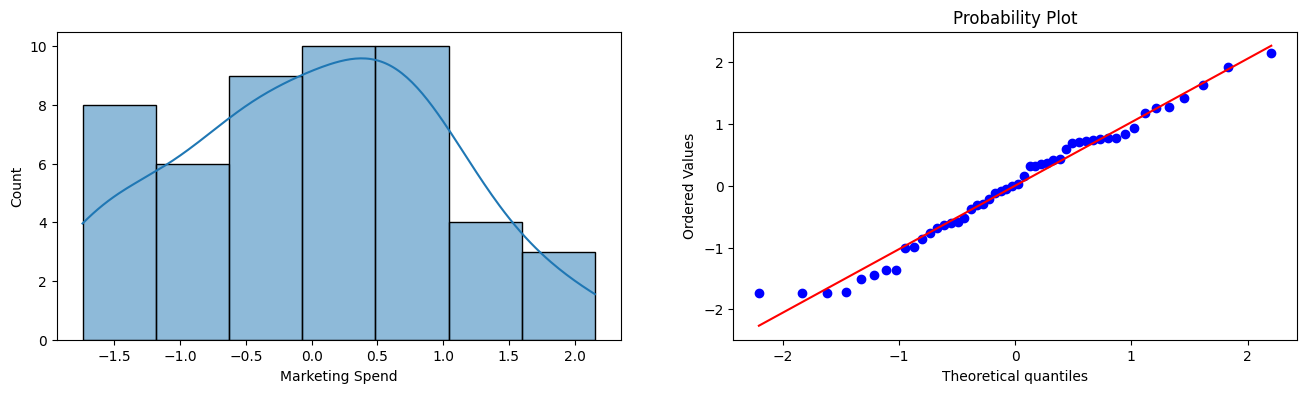

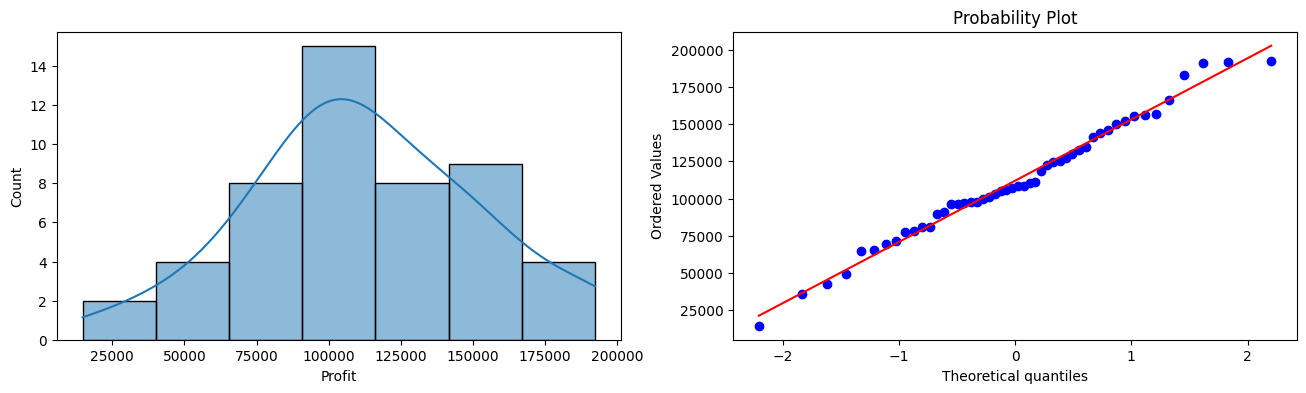

In [64]:
# Loop through all numerical columns
import scipy.stats as stats
for col in df.columns.to_list():
    
    fig,ax = plt.subplots(ncols=2,figsize=(16,4))
    
    sns.histplot(df[col], kde=True,ax = ax[0])
    stats.probplot(x=df[col] , plot=ax[1])

    
    plt.show()

### Let us fit the model and evaluate before transforming

In [86]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2 , random_state=1)

lr.fit(X_train , y_train)

y_pred = lr.predict(X_test)

print(f'r2_score -> {r2_score(y_test , y_pred)}')

r2_score -> 0.9650940934427323


In [65]:
# Step 2 Find Covariance matrix

cov_matrix = np.cov([df.iloc[:,0] ,df.iloc[:,1],df.iloc[:,2] ])

In [66]:
print(cov_matrix)

[[ 1.02040816  0.24689311  0.73902871]
 [ 0.24689311  1.02040816 -0.03281008]
 [ 0.73902871 -0.03281008  1.02040816]]


In [67]:
# Step 3 Find eigenvalues and eigenvectors of this cov_matrix
evalue , evector = np.linalg.eig(cov_matrix)

print(f"Eigenvalues -> {evalue}")
print(f"Eigenvectors -> {evector}")

Eigenvalues -> [0.23087604 1.79024143 1.04010702]
Eigenvectors -> [[-0.70223794  0.71114538 -0.03367692]
 [ 0.2473384   0.19933739 -0.94820268]
 [ 0.66759688  0.67419349  0.31587583]]


In [70]:
# Finding the 2 Best PC Unit Vecotrs (Axes)

pc = evector[:2,:]

In [74]:
# Now Let us transform our points to 2D
df_transformed = pd.DataFrame(np.dot(df.iloc[:,:-1] , pc.T) , columns = ['PC1','PC2'])
print(df_transformed.head())

df_transformed['target'] = df.iloc[:,-1]

        PC1       PC2
0 -1.089762 -1.431860
1 -0.668227 -1.124360
2 -1.804654 -1.253525
3 -1.208253 -0.983195
4 -1.867962 -1.058188


In [ ]:
print(df_transformed.head()) # Finally we have transformed our 3D Data to 2D

        PC1       PC2     target
0 -1.089762 -1.431860  192261.83
1 -0.668227 -1.124360  191792.06
2 -1.804654 -1.253525  191050.39
3 -1.208253 -0.983195  182901.99
4 -1.867962 -1.058188  166187.94


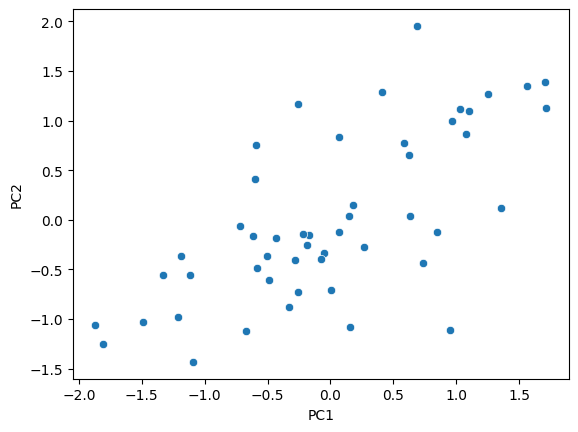

In [78]:
# Let us view this
sns.scatterplot(data = df_transformed , x='PC1' , y='PC2')
plt.show()

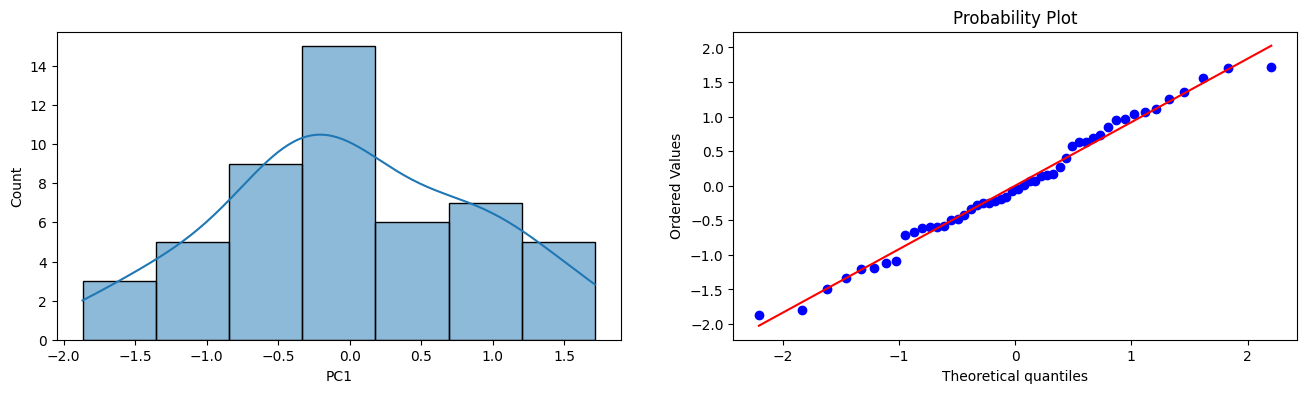

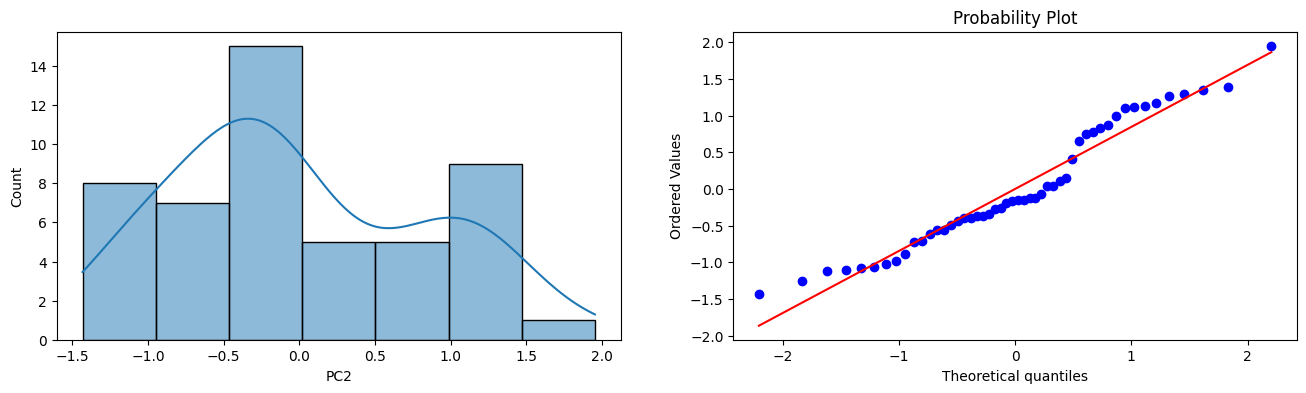

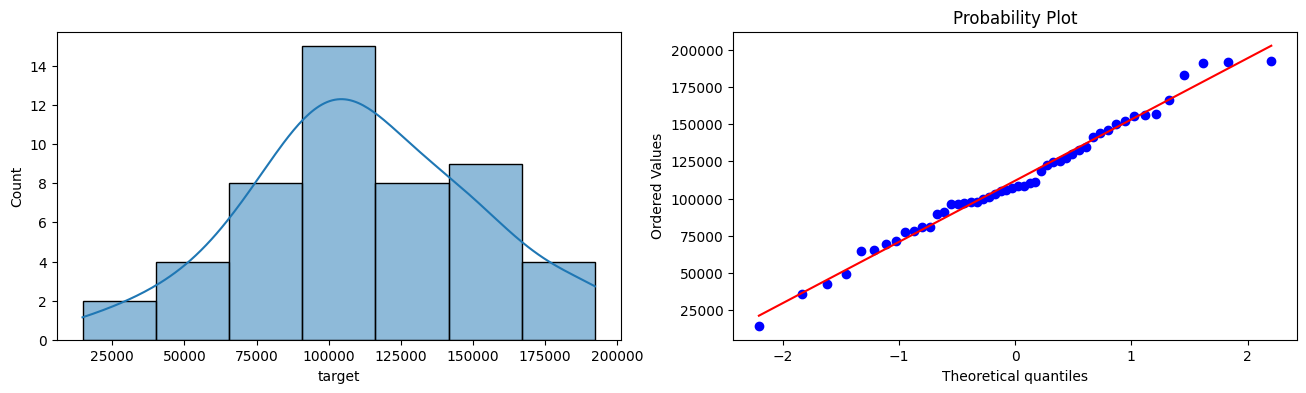

In [79]:
# Loop through all numerical columns
import scipy.stats as stats
for col in df_transformed.columns.to_list():
    
    fig,ax = plt.subplots(ncols=2,figsize=(16,4))
    
    sns.histplot(df_transformed[col], kde=True,ax = ax[0])
    stats.probplot(x=df_transformed[col] , plot=ax[1])

    
    plt.show()

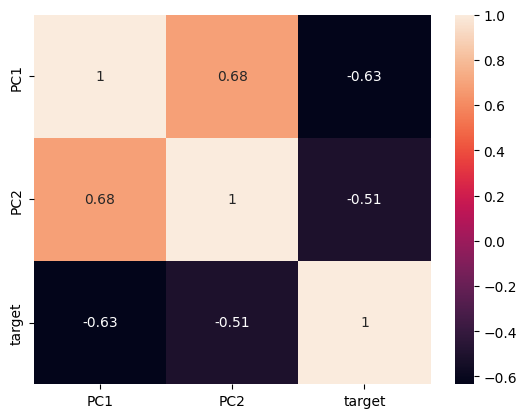

In [82]:
sns.heatmap(df_transformed.corr() , annot=True)
plt.show()

In [83]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
X = df_transformed.iloc[:,:-1]
y = df_transformed.iloc[:,-1]

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2 , random_state=1)

lr.fit(X_train , y_train)

y_pred = lr.predict(X_test)

print(f'r2_score -> {r2_score(y_test , y_pred)}')

r2_score -> 0.24299727239418967
